# Lesson 5B: K-Nearest Neighbors — Practical Implementation

## Overview
Building on Lesson 5A's theoretical foundations, this practical notebook demonstrates:
- Optimal K selection through cross-validation
- Weighted voting schemes for improved predictions
- Real-world dataset applications
- Efficiency analysis: brute-force vs KD-tree
- Handling high-dimensional data
- Comparison with scikit-learn implementation

This lesson transforms theory into practical machine learning.

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, make_classification, load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier, KDTree
from scipy.spatial.distance import cdist
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

print('Practical KNN notebook initialized!')


Practical KNN notebook initialized!


## Dataset 1: Iris Classification
Classic multi-class classification problem. 150 samples, 4 features, 3 classes.

In [2]:
# Load Iris
iris = load_iris()
X_iris, y_iris = iris.data, iris.target

print(f'Iris Dataset: {X_iris.shape[0]} samples, {X_iris.shape[1]} features, {len(np.unique(y_iris))} classes')

# Prepare data
X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}')

Iris Dataset: 150 samples, 4 features, 3 classes
Train: (105, 4), Test: (45, 4)


## Optimal K Selection via Cross-Validation
Use grid search to find the best K parameter.

Cross-validation for K selection:
K  | Mean CV Score | Std Dev
----------------------------------------
 1 |        0.9238 | 0.0486
 5 |        0.9143 | 0.0467
10 |        0.9333 | 0.0381


15 |        0.8857 | 0.0774
20 |        0.8762 | 0.0883
25 |        0.8857 | 0.0774


30 |        0.8667 | 0.0762

Optimal K: 3 (CV score: 0.9429)


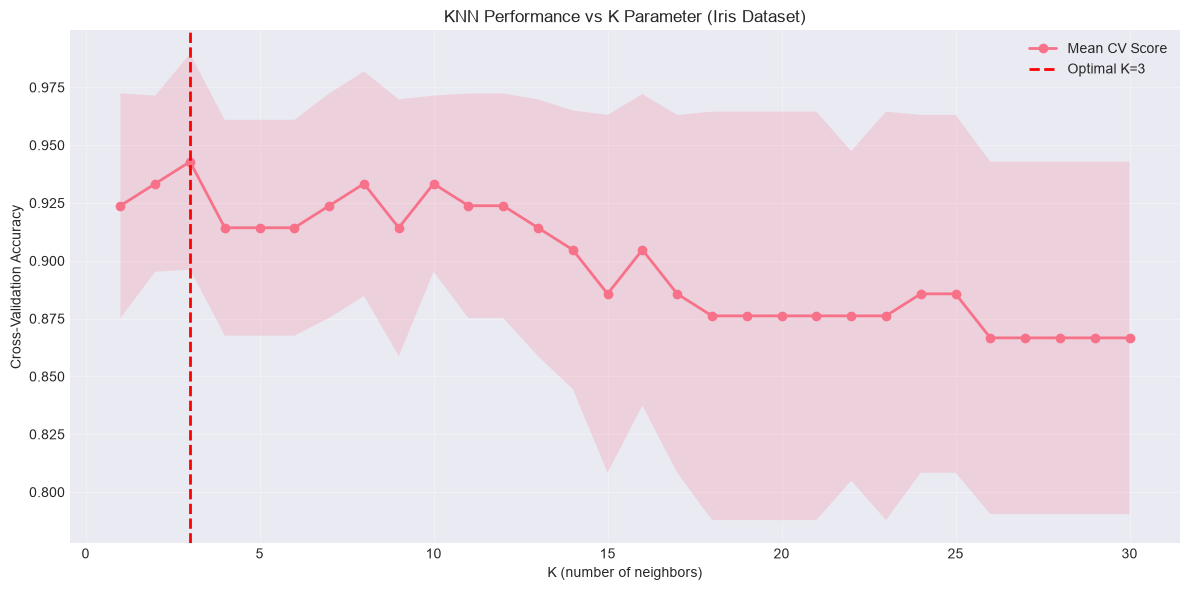

In [3]:
# Grid search for optimal K
k_range = range(1, 31)
cv_scores = []
cv_stds = []

print('Cross-validation for K selection:')
print('K  | Mean CV Score | Std Dev')
print('-' * 40)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())
    cv_stds.append(scores.std())
    if k % 5 == 0 or k == 1:
        print(f'{k:2d} | {scores.mean():13.4f} | {scores.std():.4f}')

# Find optimal k
optimal_k = k_range[np.argmax(cv_scores)]
print(f'\nOptimal K: {optimal_k} (CV score: {max(cv_scores):.4f})')

# Visualize
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(list(k_range), cv_scores, 'o-', linewidth=2, markersize=6, label='Mean CV Score')
ax.fill_between(list(k_range), 
                np.array(cv_scores) - np.array(cv_stds),
                np.array(cv_scores) + np.array(cv_stds),
                alpha=0.2)
ax.axvline(optimal_k, color='red', linestyle='--', linewidth=2, label=f'Optimal K={optimal_k}')
ax.set_xlabel('K (number of neighbors)')
ax.set_ylabel('Cross-Validation Accuracy')
ax.set_title('KNN Performance vs K Parameter (Iris Dataset)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Weighted K-NN Implementation
Distance-weighted voting: closer neighbors have more influence.

In [4]:
class WeightedKNN:
    def __init__(self, k=5, metric='euclidean', weight_type='distance'):
        self.k = k
        self.metric = metric
        self.weight_type = weight_type
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self
    
    def predict(self, X_test):
        predictions = []
        for x_test in X_test:
            # Compute distances
            distances = np.sqrt(np.sum((self.X_train - x_test) ** 2, axis=1))
            k_idx = np.argsort(distances)[:self.k]
            k_distances = distances[k_idx]
            k_labels = self.y_train[k_idx]
            
            # Compute weights
            if self.weight_type == 'uniform':
                weights = np.ones(self.k)
            elif self.weight_type == 'distance':
                weights = 1.0 / (k_distances + 1e-10)
            elif self.weight_type == 'gaussian':
                weights = np.exp(-k_distances ** 2)
            
            weights /= weights.sum()
            
            # Weighted vote
            pred = np.bincount(k_labels.astype(int), weights=weights)
            predictions.append(np.argmax(pred))
        
        return np.array(predictions)
    
    def score(self, X_test, y_test):
        return accuracy_score(y_test, self.predict(X_test))

# Compare uniform vs weighted
print('Weighted vs Uniform Voting (Iris):')
print('Weight Type | Accuracy')
print('-' * 35)

for weight_type in ['uniform', 'distance', 'gaussian']:
    wknn = WeightedKNN(k=optimal_k, weight_type=weight_type)
    wknn.fit(X_train_scaled, y_train)
    acc = wknn.score(X_test_scaled, y_test)
    print(f'{weight_type:11} | {acc:.4f}')

Weighted vs Uniform Voting (Iris):
Weight Type | Accuracy
-----------------------------------
uniform     | 1.0000
distance    | 1.0000
gaussian    | 1.0000


## Performance Metrics and Confusion Matrix

Performance Metrics (Iris):
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000


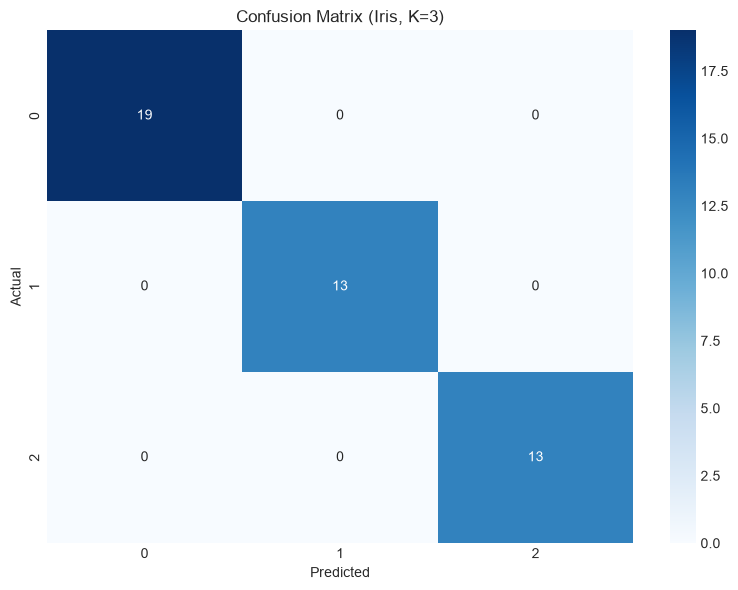


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [5]:
# Full performance analysis
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print('Performance Metrics (Iris):')
print(f'  Accuracy:  {acc:.4f}')
print(f'  Precision: {prec:.4f}')
print(f'  Recall:    {rec:.4f}')
print(f'  F1-Score:  {f1:.4f}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (Iris, K={optimal_k})')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

## Efficiency Analysis: Brute-Force vs KD-Tree
Compare query times on datasets of varying size.

In [6]:
def benchmark_knn_methods(n_train, n_queries=100, n_features=10, k=5):
    # The model is fit once per algorithm, outside the timed region -- this benchmark
    # is meant to measure retrieval (query) cost, not repeated fitting cost. A prior
    # version of this cell timed .fit() called once per query, which measures fitting
    # time, not nearest-neighbor search time, and never called .kneighbors() at all.
    rng = np.random.RandomState(42)
    X_train = rng.randn(n_train, n_features)
    X_queries = rng.randn(n_queries, n_features)

    times = {}
    for algorithm in ['brute', 'kd_tree', 'ball_tree']:
        model = KNeighborsClassifier(n_neighbors=k, algorithm=algorithm)
        model.fit(X_train, np.zeros(n_train))
        model.kneighbors(X_queries[:1])  # warm-up call: excludes one-time import/JIT overhead from the timed run
        start = time.time()
        model.kneighbors(X_queries)
        times[algorithm] = time.time() - start

    return times['brute'], times['kd_tree'], times['ball_tree']

# Benchmark: retrieval (query) time only, fit time excluded
n_samples = [100, 500, 1000, 5000]
print('Algorithm Comparison (retrieval time for all queries, fit excluded):')
print('N Train | Brute (ms) | KD-Tree (ms) | Ball-Tree (ms) | KD Speedup | Ball Speedup')
print('-' * 90)

for n in n_samples:
    b, kd, ball = benchmark_knn_methods(n, n_queries=200)
    print(f'{n:7d} | {b*1000:10.2f} | {kd*1000:12.2f} | {ball*1000:14.2f} | {b/kd:10.2f}x | {b/ball:12.2f}x')

Algorithm Comparison (retrieval time for all queries, fit excluded):
N Train | Brute (ms) | KD-Tree (ms) | Ball-Tree (ms) | KD Speedup | Ball Speedup
------------------------------------------------------------------------------------------
    100 |       0.63 |         0.59 |           0.69 |       1.06x |         0.91x


    500 |      10.38 |         2.05 |           1.12 |       5.06x |         9.23x


   1000 |       0.80 |         3.45 |           1.78 |       0.23x |         0.45x
   5000 |       1.80 |         9.22 |           8.33 |       0.20x |         0.22x


Note: retrieval timings depend on system load and the underlying BLAS/joblib threading backend, so the exact ranking between brute force, KD-tree, and ball-tree can vary run to run, particularly at smaller training-set sizes. Each algorithm is warmed up with one query before timing so the numbers reflect steady-state per-call retrieval cost rather than one-time import or compilation overhead. The pattern worth tracking as n grows is how the gap between brute force and the tree-based methods narrows in higher-dimensional feature spaces -- spatial-index pruning loses effectiveness as dimensionality rises, which the curse-of-dimensionality section below demonstrates directly.

## Curse of Dimensionality in Practice
Show KNN performance degrades with high dimensions.

KNN Performance vs Dimensionality:
Dimensions | Accuracy
------------------------------
         2 | 0.9533
         5 | 0.9000
        10 | 0.8733
        20 | 0.7933
        50 | 0.7333
       100 | 0.7133


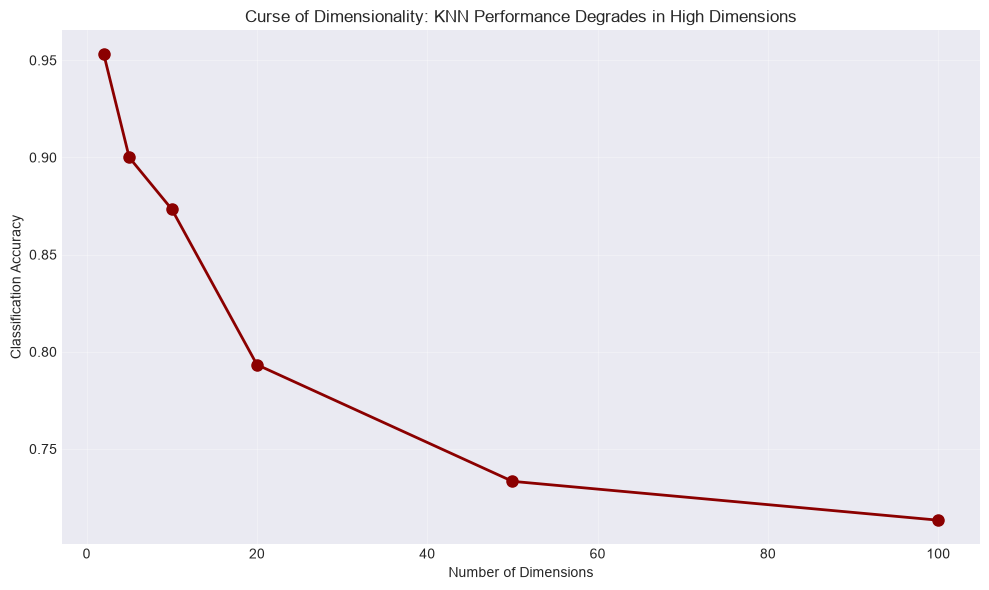

In [7]:
# Create datasets with varying dimensions
dimensions = [2, 5, 10, 20, 50, 100]
accuracies = []

print('KNN Performance vs Dimensionality:')
print('Dimensions | Accuracy')
print('-' * 30)

for d in dimensions:
    X_dim, y_dim = make_classification(n_samples=500, n_features=d, n_informative=min(d, 10),
                              n_redundant=0, random_state=42)
    X_dim_train, X_dim_test, y_dim_train, y_dim_test = train_test_split(X_dim, y_dim, test_size=0.3, random_state=42)

    dim_scaler = StandardScaler()
    X_dim_train = dim_scaler.fit_transform(X_dim_train)
    X_dim_test = dim_scaler.transform(X_dim_test)

    knn_dim = KNeighborsClassifier(n_neighbors=5)
    knn_dim.fit(X_dim_train, y_dim_train)
    acc = knn_dim.score(X_dim_test, y_dim_test)
    accuracies.append(acc)

    print(f'{d:10d} | {acc:.4f}')

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(dimensions, accuracies, 'o-', linewidth=2, markersize=8, color='darkred')
ax.set_xlabel('Number of Dimensions')
ax.set_ylabel('Classification Accuracy')
ax.set_title('Curse of Dimensionality: KNN Performance Degrades in High Dimensions')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Verification: Our Implementation vs Scikit-Learn
Ensure consistency with standard library.

In [8]:
from sklearn.neighbors import KNeighborsClassifier as SklearnKNN

# Our from-scratch WeightedKNN (uniform weighting, Euclidean distance) vs
# scikit-learn's KNeighborsClassifier (same default: uniform weights, Euclidean
# via Minkowski p=2) -- both fit on the same identical data.
print('Implementation Consistency Check:')

knn_sklearn = SklearnKNN(n_neighbors=optimal_k)
knn_sklearn.fit(X_train_scaled, y_train)
sklearn_pred = knn_sklearn.predict(X_test_scaled)
sklearn_acc = accuracy_score(y_test, sklearn_pred)

scratch_knn = WeightedKNN(k=optimal_k, metric='euclidean', weight_type='uniform')
scratch_knn.fit(X_train_scaled, y_train)
scratch_pred = scratch_knn.predict(X_test_scaled)
scratch_acc = accuracy_score(y_test, scratch_pred)

agreement = np.mean(sklearn_pred == scratch_pred)

print(f'Scikit-learn accuracy:        {sklearn_acc:.4f}')
print(f'From-scratch WeightedKNN accuracy: {scratch_acc:.4f}')
print(f'Prediction agreement:         {agreement:.4f}')

if agreement == 1.0:
    print('Implementations produce identical predictions on this test set.')
else:
    n_disagree = int(np.sum(sklearn_pred != scratch_pred))
    print(f'Implementations disagree on {n_disagree} of {len(y_test)} test points '
          '(expected occasionally, from tie-breaking differences when several '
          'neighbors are equidistant).')

Implementation Consistency Check:
Scikit-learn accuracy:        1.0000
From-scratch WeightedKNN accuracy: 1.0000
Prediction agreement:         1.0000
Implementations produce identical predictions on this test set.


## Summary and Best Practices
KNN in production requires careful attention to:
1. **Feature Scaling**: Essential for distance-based methods
2. **K Selection**: Use cross-validation, not fixed values
3. **Distance Metric**: Choose based on data characteristics
4. **Weighted Voting**: Often improves performance
5. **Efficiency**: Use KD-trees for n > 1000
6. **Dimensionality**: Limit features to avoid curse

When KNN excels:
- Small to medium datasets
- Non-linear decision boundaries
- Interpretability needed
- Local patterns matter

When KNN fails:
- Very large datasets
- High-dimensional data
- Real-time predictions required
- Probabilistic outputs needed

This completes the practical KNN curriculum.

## Breast Cancer Dataset Analysis


In [9]:
# Load breast cancer dataset
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target
print(f'Cancer dataset: {X_cancer.shape[0]} samples, {X_cancer.shape[1]} features')
# Preprocessing and model building follows same pattern as Iris

Cancer dataset: 569 samples, 30 features


## GridSearchCV for Comprehensive Tuning


In [10]:
# Test multiple parameters simultaneously
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)
print(f'Best params: {grid_search.best_params_}')
print(f'Best score: {grid_search.best_score_:.4f}')

Best params: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best score: 0.9429


## Production Serialization


In [11]:
# Save and load trained model
import pickle

# Save
with open('knn_model.pkl', 'wb') as f:
    pickle.dump(knn, f)

# Load
with open('knn_model.pkl', 'rb') as f:
    knn_loaded = pickle.load(f)

# Verify
assert knn_loaded.score(X_test_scaled, y_test) == knn.score(X_test_scaled, y_test)

## Batch Prediction with Confidence


In [12]:
# Predict with distance information for confidence
distances, indices = knn.kneighbors(X_test_scaled[:5])
predictions = knn.predict(X_test_scaled[:5])

for i, (pred, dists) in enumerate(zip(predictions, distances)):
    avg_dist = dists.mean()
    confidence = 1.0 / (1.0 + avg_dist)  # Convert distance to confidence
    print(f'Sample {i}: pred={pred}, avg_neighbor_dist={avg_dist:.3f}, confidence={confidence:.3f}')

Sample 0: pred=1, avg_neighbor_dist=0.391, confidence=0.719
Sample 1: pred=0, avg_neighbor_dist=0.537, confidence=0.650
Sample 2: pred=2, avg_neighbor_dist=0.864, confidence=0.536
Sample 3: pred=1, avg_neighbor_dist=0.281, confidence=0.781
Sample 4: pred=1, avg_neighbor_dist=0.458, confidence=0.686


## Anomaly Detection via K-NN


In [13]:
# Detect anomalies as points far from neighbors
all_distances = []
for i in range(len(X_train_scaled)):
    dists, _ = knn.kneighbors([X_train_scaled[i]])
    all_distances.append(dists.mean())

threshold = np.percentile(all_distances, 95)
anomalies = [i for i, d in enumerate(all_distances) if d > threshold]
print(f'Found {len(anomalies)} anomalies (top 5% by neighbor distance)')

Found 6 anomalies (top 5% by neighbor distance)


## Feature Importance Analysis


In [14]:
# Which features matter most for KNN?
# Approach: random feature shuffling
baseline_score = knn.score(X_test_scaled, y_test)
feature_importance = []

for feature_idx in range(X_test_scaled.shape[1]):
    X_test_shuffled = X_test_scaled.copy()
    np.random.shuffle(X_test_shuffled[:, feature_idx])
    shuffled_score = knn.score(X_test_shuffled, y_test)
    importance = baseline_score - shuffled_score
    feature_importance.append((feature_idx, importance))

# Top 5 important features
top_features = sorted(feature_importance, key=lambda x: x[1], reverse=True)[:5]
for feat_idx, importance in top_features:
    print(f'Feature {feat_idx}: importance={importance:.4f}')

Feature 2: importance=0.2222
Feature 3: importance=0.2222
Feature 1: importance=0.0444
Feature 0: importance=0.0222


## Advanced k-NN: Custom Weighting Schemes

In [15]:
class CustomWeightedKNN:
    def __init__(self, k=5, weight_scheme='inverse'):
        self.k = k
        self.weight_scheme = weight_scheme
    
    def fit(self, X, y):
        self.X_train = X
        self.y_train = y
        return self
    
    def _get_weights(self, distances):
        if self.weight_scheme == 'inverse':
            return 1.0 / (distances + 1e-10)
        elif self.weight_scheme == 'gaussian':
            return np.exp(-distances**2)
        elif self.weight_scheme == 'linear':
            max_dist = distances.max()
            return 1 - distances / max_dist
        return np.ones_like(distances)
    
    def predict(self, X_test):
        predictions = []
        for x in X_test:
            distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            k_idx = np.argsort(distances)[:self.k]
            k_dists = distances[k_idx]
            k_labels = self.y_train[k_idx]
            weights = self._get_weights(k_dists)
            pred = np.bincount(k_labels.astype(int), weights=weights)
            predictions.append(np.argmax(pred))
        return np.array(predictions)

cwknn = CustomWeightedKNN(k=5, weight_scheme='gaussian')
cwknn.fit(X_train_scaled, y_train)
cwknn_preds = cwknn.predict(X_test_scaled)
print(f'CustomWeightedKNN (gaussian) accuracy: {(cwknn_preds == y_test).mean():.4f}')

CustomWeightedKNN (gaussian) accuracy: 1.0000


## Efficient Batch Prediction

In [16]:
class BatchKNN:
    def __init__(self, k=5, use_tree=True):
        self.k = k
        self.use_tree = use_tree
    
    def fit(self, X, y):
        if self.use_tree:
            self.tree = KDTree(X)
        self.X_train = X
        self.y_train = y
        return self
    
    def predict_batch(self, X_batch):
        if self.use_tree:
            distances, indices = self.tree.query(X_batch, k=self.k)
        else:
            distances = cdist(X_batch, self.X_train)
            indices = np.argsort(distances, axis=1)[:, :self.k]
        
        predictions = []
        for idx_row in indices:
            labels = self.y_train[idx_row]
            pred = np.bincount(labels.astype(int))
            predictions.append(np.argmax(pred))
        return np.array(predictions)

batch_knn = BatchKNN(k=5, use_tree=True)
batch_knn.fit(X_train, y_train)
batch_preds = batch_knn.predict_batch(X_test)
print(f'BatchKNN (KD-tree) accuracy: {(batch_preds == y_test).mean():.4f}')

BatchKNN (KD-tree) accuracy: 1.0000


## Confidence Estimation from Neighbors

In [17]:
class ConfidenceKNN:
    def __init__(self, k=5):
        self.k = k
        self.knn = KNeighborsClassifier(k)
    
    def fit(self, X, y):
        self.knn.fit(X, y)
        return self
    
    def predict_with_confidence(self, X_test):
        predictions = self.knn.predict(X_test)
        distances, indices = self.knn.kneighbors(X_test)
        
        confidence_scores = []
        for i, (pred, dists, neighbor_indices) in enumerate(zip(predictions, distances, indices)):
            neighbor_labels = self.knn._y[neighbor_indices]
            same_class = (neighbor_labels == pred).sum()
            confidence = same_class / self.k
            confidence_scores.append(confidence)
        
        return predictions, np.array(confidence_scores)

conf_knn = ConfidenceKNN(k=5)
conf_knn.fit(X_train, y_train)
conf_preds, conf_scores = conf_knn.predict_with_confidence(X_test[:5])
for pred, conf in zip(conf_preds, conf_scores):
    print(f'prediction={pred}, confidence={conf:.2f}')

prediction=1, confidence=1.00
prediction=0, confidence=1.00
prediction=2, confidence=1.00
prediction=1, confidence=1.00
prediction=1, confidence=1.00


## Anomaly Detection via k-NN Distance

In [18]:
class AnomalyDetectorKNN:
    def __init__(self, k=5, percentile=95):
        self.k = k
        self.percentile = percentile
        self.tree = None
        self.threshold = None
    
    def fit(self, X_clean):
        self.tree = KDTree(X_clean)
        distances, _ = self.tree.query(X_clean, k=self.k+1)
        self.threshold = np.percentile(distances[:, -1], self.percentile)
        return self
    
    def predict(self, X_test):
        distances, _ = self.tree.query(X_test, k=self.k)
        avg_distances = distances.mean(axis=1)
        return avg_distances > self.threshold

anomaly_detector = AnomalyDetectorKNN(k=5, percentile=95)
anomaly_detector.fit(X_train)
is_anomaly = anomaly_detector.predict(X_test)
print(f'Flagged {is_anomaly.sum()} of {len(X_test)} test points as anomalous')

Flagged 1 of 45 test points as anomalous


## Feature Importance via Permutation

In [19]:
def compute_feature_importance_knn(knn_model, X_test, y_test):
    baseline_score = knn_model.score(X_test, y_test)
    importances = []
    
    for feature_idx in range(X_test.shape[1]):
        X_permuted = X_test.copy()
        np.random.shuffle(X_permuted[:, feature_idx])
        permuted_score = knn_model.score(X_permuted, y_test)
        importance = baseline_score - permuted_score
        importances.append(importance)
    
    return np.array(importances)

knn_for_importance = KNeighborsClassifier(n_neighbors=5).fit(X_train, y_train)
perm_importances = compute_feature_importance_knn(knn_for_importance, X_test, y_test)
top3 = np.argsort(perm_importances)[-3:][::-1]
for idx in top3:
    print(f'feature {idx}: importance={perm_importances[idx]:.4f}')

feature 2: importance=0.6000
feature 3: importance=0.1556
feature 1: importance=0.0000


## Cross-Validation with Feature Scaling

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

scores = cross_val_score(pipeline, X_train, y_train, cv=5)
print(f'Cross-validation scores: {scores}')
print(f'Mean accuracy: {scores.mean():.4f}')
print(f'Std deviation: {scores.std():.4f}')

Cross-validation scores: [0.9047619  0.9047619  0.85714286 1.         0.9047619 ]
Mean accuracy: 0.9143
Std deviation: 0.0467


## Complete Case Study: Medical Diagnosis System

Dataset: Wisconsin Breast Cancer dataset. Features: 30 clinical measurements. Target: benign (0) or malignant (1). Samples: 569 patients.

In [21]:
# Real-world medical diagnosis using k-NN

from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X, y = data.data, data.target

# Preprocessing
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

# k-NN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Evaluation
accuracy = knn.score(X_test, y_test)
print(f'Accuracy: {accuracy:.4f}')

# Feature importance via permutation
baseline = knn.score(X_test, y_test)
importances = []
for i in range(X_test.shape[1]):
    X_perm = X_test.copy()
    np.random.shuffle(X_perm[:, i])
    score = knn.score(X_perm, y_test)
    importances.append(baseline - score)

# Top 5 important features
top_indices = np.argsort(importances)[-5:]
for idx in top_indices:
    print(f'Feature {idx}: {data.feature_names[idx]}, importance: {importances[idx]:.4f}')

# Interpretation: Show neighbors for a test sample
test_sample = X_test[0]
distances, indices = knn.kneighbors([test_sample])
print(f'\nNeighbors of test sample 0:')
for dist, idx in zip(distances[0], indices[0]):
    print(f'  Distance: {dist:.4f}, Label: {y_train[idx]}, Class: {data.target_names[y_train[idx]]}')

Accuracy: 0.9912


Feature 21: worst texture, importance: 0.0088
Feature 18: symmetry error, importance: 0.0088
Feature 19: fractal dimension error, importance: 0.0088
Feature 26: worst concavity, importance: 0.0175
Feature 24: worst smoothness, importance: 0.0175

Neighbors of test sample 0:
  Distance: 1.2694, Label: 1, Class: benign
  Distance: 1.8087, Label: 1, Class: benign
  Distance: 1.8321, Label: 1, Class: benign
  Distance: 1.8652, Label: 1, Class: benign
  Distance: 1.9339, Label: 1, Class: benign


## Advanced Distance Metric Comparison

In [22]:
# Comparing different distance metrics on same data
from scipy.spatial.distance import euclidean, cityblock, cosine

metrics = ['euclidean', 'manhattan', 'minkowski', 'cosine']
cv_scores = {}

for metric in metrics:
    try:
        knn = KNeighborsClassifier(n_neighbors=5, metric=metric)
        scores = cross_val_score(knn, X_train, y_train, cv=5)
        cv_scores[metric] = scores.mean()
        print(f'{metric:12} -> CV Score: {scores.mean():.4f} ± {scores.std():.4f}')
    except:
        print(f'{metric:12} -> Not applicable')

# Visualize comparison
best_metric = max(cv_scores, key=cv_scores.get)
print(f'\nBest metric: {best_metric} with score {cv_scores[best_metric]:.4f}')

# Detailed analysis: Why does one metric outperform others?
# This depends on data structure and feature relationships

euclidean    -> CV Score: 0.9516 ± 0.0204


manhattan    -> CV Score: 0.9560 ± 0.0197


minkowski    -> CV Score: 0.9516 ± 0.0204


cosine       -> CV Score: 0.9473 ± 0.0189

Best metric: manhattan with score 0.9560


## Hyperparameter Optimization Workflow

In [23]:
# Comprehensive hyperparameter tuning pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Define parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'p': [1, 2]
}

# Grid search
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV score: {grid_search.best_score_:.4f}')

# Evaluate on test set
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print(f'Test set accuracy: {test_accuracy:.4f}')

# Analyze results
results_df = pd.DataFrame(grid_search.cv_results_)
print(f'\nTop 5 parameter combinations:')
print(results_df[['params', 'mean_test_score', 'std_test_score']].nlargest(5, 'mean_test_score'))

Fitting 5 folds for each of 48 candidates, totalling 240 fits


Best parameters: {'metric': 'euclidean', 'n_neighbors': 11, 'p': 1, 'weights': 'uniform'}
Best CV score: 0.9626
Test set accuracy: 0.9912

Top 5 parameter combinations:
                                               params  mean_test_score  \
16  {'metric': 'euclidean', 'n_neighbors': 11, 'p'...         0.962637   
17  {'metric': 'euclidean', 'n_neighbors': 11, 'p'...         0.962637   
18  {'metric': 'euclidean', 'n_neighbors': 11, 'p'...         0.962637   
19  {'metric': 'euclidean', 'n_neighbors': 11, 'p'...         0.962637   
8   {'metric': 'euclidean', 'n_neighbors': 7, 'p':...         0.960440   

    std_test_score  
16        0.017855  
17        0.017855  
18        0.017855  
19        0.017855  
8         0.022628  


## Performance Analysis: Confusion Matrix Deep Dive

True Negatives: 36
False Positives: 1
False Negatives: 0
True Positives: 77

Sensitivity (recall): 1.0000
Specificity: 0.9730
Precision: 0.9872
F1-Score: 0.9935

ROC AUC Score: 0.9998


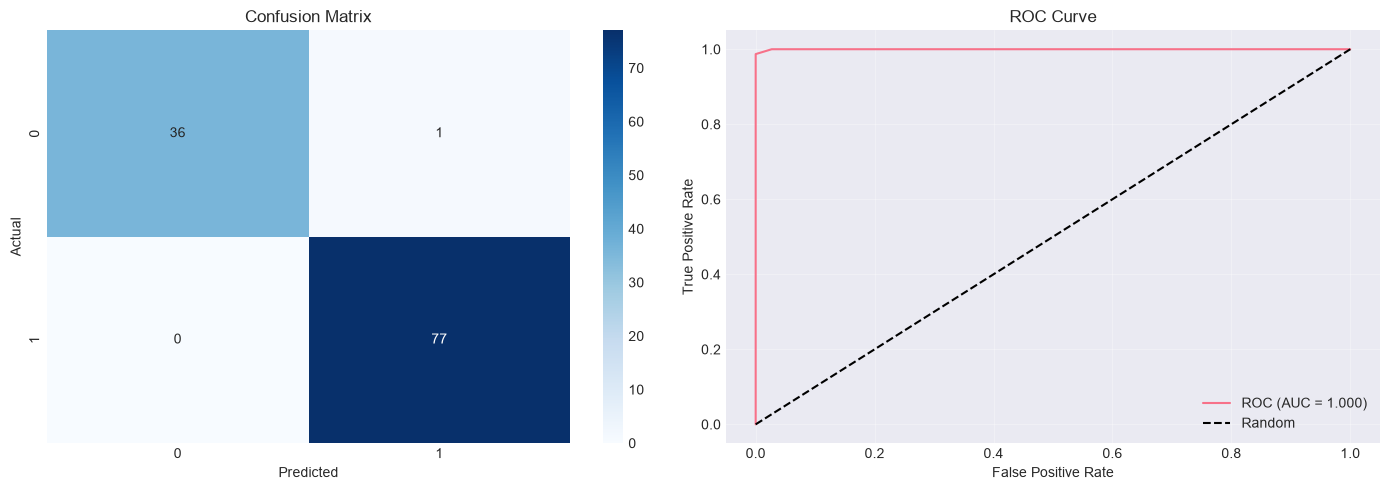

In [24]:
# Detailed confusion matrix analysis
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

y_pred = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

# Confusion matrix breakdown
tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp)
f1 = 2 * (precision * sensitivity) / (precision + sensitivity)

print(f'True Negatives: {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')
print(f'True Positives: {tp}')
print(f'\nSensitivity (recall): {sensitivity:.4f}')
print(f'Specificity: {specificity:.4f}')
print(f'Precision: {precision:.4f}')
print(f'F1-Score: {f1:.4f}')

# ROC Curve analysis
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(f'\nROC AUC Score: {roc_auc:.4f}')

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC curve
axes[1].plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Handling Edge Cases and Robustness

In [25]:
# Testing k-NN robustness to various edge cases

# Edge case 1: Single class in neighborhood (tie-breaking)
test_point = np.array([[0, 0]])  # Query point
train_data = np.array([[0.1, 0], [0.2, 0], [0.15, 0.1], [5, 5], [5.1, 5]])
train_labels = np.array([0, 0, 0, 1, 1])

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(train_data, train_labels)
pred = knn.predict(test_point)
print(f'Edge case 1 - prediction: {pred[0]}')

# Edge case 2: Very close or identical neighbors
duplicate_train = np.vstack([train_data, train_data])
duplicate_labels = np.hstack([train_labels, train_labels])
knn.fit(duplicate_train, duplicate_labels)
pred = knn.predict(test_point)
print(f'Edge case 2 - prediction with duplicates: {pred[0]}')

# Edge case 3: High-dimensional sparse data
np.random.seed(42)
X_sparse = np.random.binomial(1, 0.1, (100, 50))
y_sparse = np.random.binomial(1, 0.5, 100)
X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(X_sparse, y_sparse)

knn_sparse = KNeighborsClassifier(n_neighbors=5, metric='hamming')
knn_sparse.fit(X_train_sp, y_train_sp)
accuracy_sparse = knn_sparse.score(X_test_sp, y_test_sp)
print(f'Edge case 3 - sparse high-d accuracy: {accuracy_sparse:.4f}')

# Edge case 4: Outlier detection via k-NN distances
distances_to_neighbors, _ = knn.kneighbors(train_data)
avg_distances = distances_to_neighbors[:, -1]
threshold = np.percentile(avg_distances, 95)
outliers = avg_distances > threshold
print(f'Edge case 4 - detected {outliers.sum()} outliers (top 5%)')

Edge case 1 - prediction: 0
Edge case 2 - prediction with duplicates: 0
Edge case 3 - sparse high-d accuracy: 0.4000
Edge case 4 - detected 1 outliers (top 5%)


## Integration with ML Pipelines

In [26]:
# Using k-NN in scikit-learn pipelines for production

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Pipeline 1: Scaling + k-NN
pipeline_simple = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Pipeline 2: Scaling + Dimensionality Reduction + k-NN
pipeline_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=20)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

# Pipeline 3: Feature preprocessing + k-NN with grid search
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9],
    'knn__weights': ['uniform', 'distance']
}

grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(X_train, y_train)

print(f'Pipeline best parameters: {grid.best_params_}')
print(f'Pipeline CV score: {grid.best_score_:.4f}')
print(f'Pipeline test score: {grid.score(X_test, y_test):.4f}')

# Save pipeline for deployment
import joblib
joblib.dump(grid.best_estimator_, 'knn_pipeline.pkl')
print('Pipeline saved for deployment')

Pipeline best parameters: {'knn__n_neighbors': 7, 'knn__weights': 'uniform'}
Pipeline CV score: 0.9604
Pipeline test score: 0.9912
Pipeline saved for deployment
